## HW 9: SciPy!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [4]:
noisy_data = pd.read_csv("noisy_curvefit_data.csv")
noisy_data

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113
...,...,...,...,...,...,...
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548


In [5]:
print(f"Data Shape: {noisy_data.shape} | Number of Rows: {noisy_data.shape[0]} | Number of Columns: {noisy_data.shape[1]}")
print(f"Column Names: {noisy_data.columns}")
print("First Five Rows:")
noisy_data.head()

Data Shape: (100, 6) | Number of Rows: 100 | Number of Columns: 6
Column Names: Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')
First Five Rows:


,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [6]:
print("Last Five Rows")
noisy_data.tail()

Last Five Rows


,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


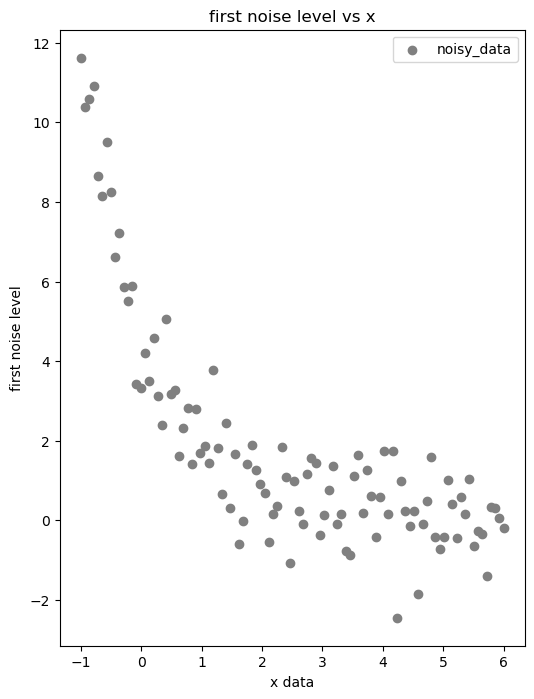

In [11]:
plt.figure(figsize = (6,8))
plt.scatter(noisy_data["x"], noisy_data["y_noise_1"], label = "noisy_data", color = "gray")
plt.xlabel("x data")
plt.ylabel("first noise level")
plt.title("first noise level vs x")
plt.legend()
plt.show()

In [14]:
x = noisy_data["x"]
y_noise_1 = noisy_data["y_noise_1"]
def model(x, A, k):
    return A * np.exp(-k * x)

In [15]:
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt

In [16]:
print(f"Best Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Best Fit: y = 4.71 * e^(-0.92 * x)


In [17]:
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

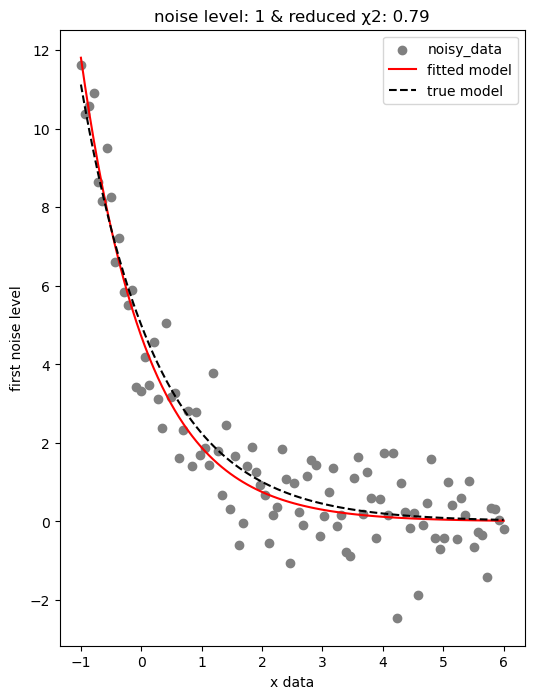

In [19]:
plt.figure(figsize = (6,8))
plt.scatter(noisy_data["x"], noisy_data["y_noise_1"], label = "noisy_data", color = "gray")
plt.plot(x, model(x, A_fit, k_fit), color = "red", label = "fitted model")
plt.plot(x, model(x, 5, 0.8), color = "black", linestyle = "--", label = "true model")
plt.xlabel("x data")
plt.ylabel("first noise level")
plt.title(f"noise level: 1 & reduced χ2: {chi2_reduced:.2f}")
plt.legend()
plt.show()

In [20]:
def fit_model(x,y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof

    return A_fit, k_fit, chi2_reduced

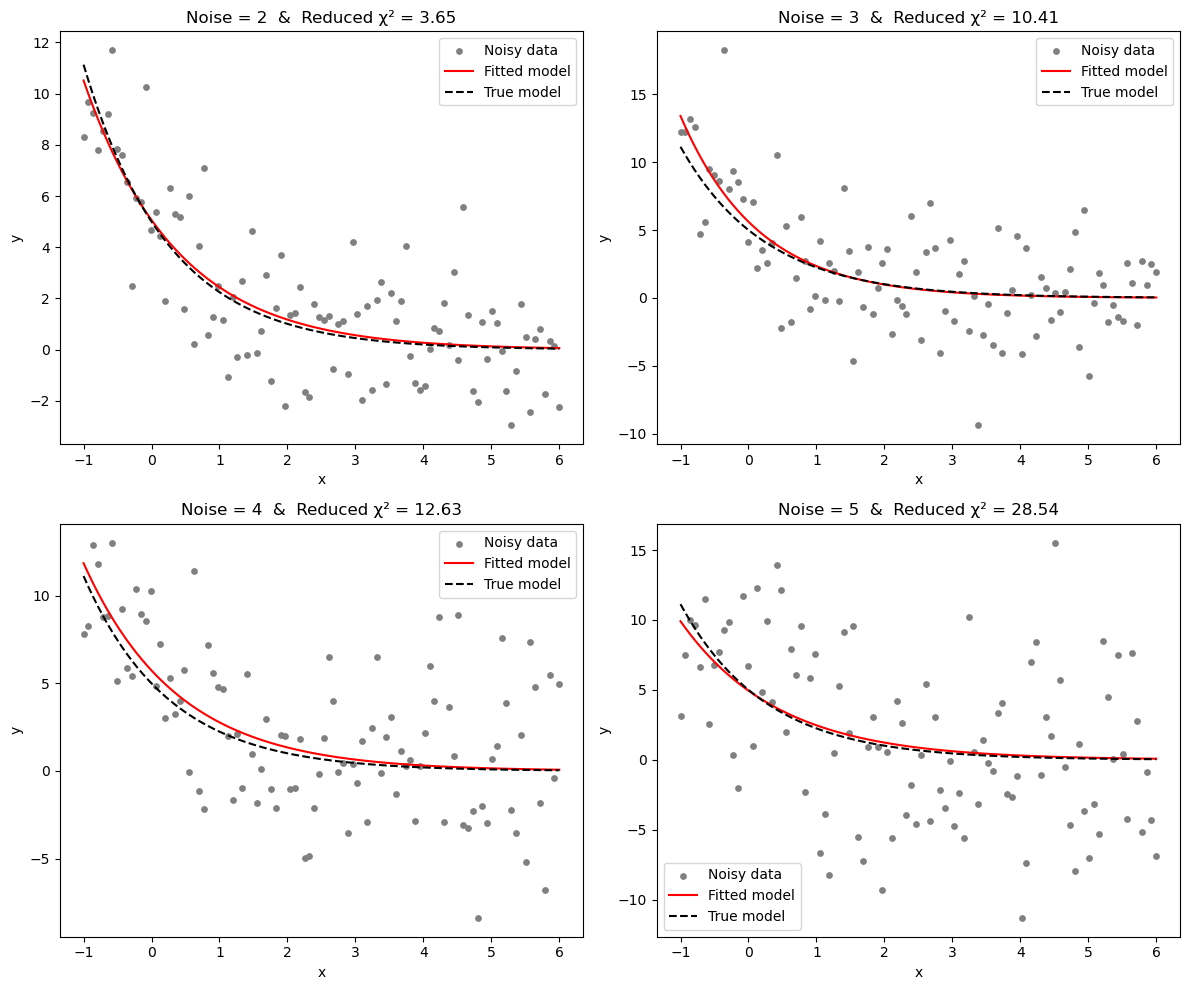

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

noise_cols = [2, 3, 4, 5] # noise levels happen to be the same as their column indices because of that first x column

for ax, col_idx in zip(axes.flatten(), noise_cols):

    y = noisy_data.iloc[:, col_idx]   
    noise_level = col_idx             

    A_fit, k_fit, chi2_red = fit_model(x, y)

    
    ax.scatter(x, y, color="gray", s=15, label="Noisy data")

  
    ax.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted model")

    
    ax.plot(x, model(x, 5, 0.8), color="black", linestyle="--", label="True model")

  
    ax.set_title(f"Noise = {noise_level}  &  Reduced χ² = {chi2_red:.2f}")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

plt.tight_layout()
plt.show()

As you increase the noise level

As you increase the noise level, the reduced chi2 increases. This is because increasing the noise means the data points are further away from the true curve/model, so a poorer fit is expected. And since a chi2 of 1 is meant to be ideal, it's clear how the noise level interferes with the fit of the model.